In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import sys
!{sys.executable} -m pip install "transformers[torch]" accelerate -U
!pip install captum
!pip install torchinfo

In [3]:
# %% [markdown]
# # Textile Defect Detection (Kaggle TextileDefectDetection) — Clean Baseline
# This script keeps the original pipeline and paths, but is reorganized for clarity.
#
# Pipeline:
# 1) Merge raw train/test CSV + H5 into a single processed dataset
# 2) Compute MD5 hashes to analyze exact duplicates / leakage
# 3) Deduplicate within each original split, then stratified Train/Val split
# 4) Train a small CNN classifier with Early Stopping

In [4]:

# ## 1. Imports & Configuration

import copy
import hashlib
import json
import os
from collections import defaultdict
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import h5py
import math
import warnings
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import Normalize, Resize, ToTensor, Compose, GaussianBlur
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer, set_seed, EarlyStoppingCallback
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, Dataset
import shutil
from pathlib import Path

# Disable HDF5 file locking for better compatibility
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Path configuration (DO NOT CHANGE)
ROOT = Path.cwd()
ROOT = ROOT / "drive" / "MyDrive" / "Term_Project"
RAW = ROOT / "data" / "raw" / "textile"
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"
PROCESSED.mkdir(parents=True, exist_ok=True)

# File paths (DO NOT CHANGE)
TRAIN_H5, TRAIN_CSV = RAW / "train64.h5", RAW / "train64.csv"
TEST_H5, TEST_CSV = RAW / "test64.h5", RAW / "test64.csv"
OUT_H5, OUT_CSV = PROCESSED / "full64.h5", PROCESSED / "full64.csv"

# Device setup
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch, "backends") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    try:
        import torch_directml  # type: ignore

        device = torch_directml.device()
    except ImportError:
        pass
#set random seed
set_seed(42)

def _require_file(path: Path) -> None:
    """Fail fast when a required file is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")


def _normalize_label(x) -> str:
    return str(x).strip()


def print_class_counts(df: pd.DataFrame, title: str) -> None:
    """Print total rows and per-class distribution for the given dataframe."""
    if "indication_type" not in df.columns:
        print(f"[{title}] Missing column: indication_type")
        return

    vc = df["indication_type"].astype(str).str.strip().value_counts()
    print(f"\n[{title}] total_images={len(df)}")
    for k, v in vc.items():
        print(f"  {k}: {v}")


In [5]:
# ## 2. Merge Raw Train/Test into Processed Full Dataset

def merge_data() -> None:
    """
    Merge separate train/test H5 and CSV files into a unified dataset.

    Outputs:
      - data/processed/full64.csv
      - data/processed/full64.h5
    """
    if OUT_H5.exists() and OUT_CSV.exists():
        print("Dataset already merged. Skipping merge.")
        return

    _require_file(TRAIN_CSV)
    _require_file(TEST_CSV)
    _require_file(TRAIN_H5)
    _require_file(TEST_H5)

    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)

    # Keep original split info
    df_train["original_split"] = "train"
    df_test["original_split"] = "test"

    full_df = pd.concat([df_train, df_test], ignore_index=True)
    full_df.to_csv(OUT_CSV, index=False)
    print(f"Saved merged CSV: {OUT_CSV}")

    with h5py.File(OUT_H5, "w") as f_out:
        with h5py.File(TRAIN_H5, "r") as f_tr, h5py.File(TEST_H5, "r") as f_te:
            tr_imgs = f_tr["images"]
            te_imgs = f_te["images"]

            total_shape = (tr_imgs.shape[0] + te_imgs.shape[0], *tr_imgs.shape[1:])
            dset = f_out.create_dataset("images", shape=total_shape, dtype="f")  # keep original dtype choice

            dset[: tr_imgs.shape[0]] = tr_imgs[:]
            dset[tr_imgs.shape[0] :] = te_imgs[:]

    print(f"Saved merged H5: {OUT_H5}")


In [6]:
# ## 3. MD5 Hashing & Duplicate Analysis

def get_h5_hashes(h5_path: Path, total_images: int, chunk_size: int = 5000) -> List[str]:
    """Generate MD5 fingerprints for all images in the H5 file."""
    hashes: List[str] = [""] * total_images
    print(f"Generating MD5 fingerprints for {total_images} images...")

    with h5py.File(h5_path, "r") as f:
        images = f["images"]
        for start in range(0, total_images, chunk_size):
            end = min(start + chunk_size, total_images)
            chunk = images[start:end]
            for i, img in enumerate(chunk):
                hashes[start + i] = hashlib.md5(img.tobytes()).hexdigest()

    return hashes


def analyze_duplicates() -> List[str]:
    """
    Identify exact duplicates via MD5 and check leakage across original splits.

    Output:
      - data/processed/duplicates_report.csv (if duplicates exist)
    """
    _require_file(OUT_CSV)
    _require_file(OUT_H5)

    df = pd.read_csv(OUT_CSV)
    with h5py.File(OUT_H5, "r") as f:
        total = int(f["images"].shape[0])

    all_hashes = get_h5_hashes(OUT_H5, total)

    hash_map: Dict[str, List[int]] = defaultdict(list)
    for idx, h in enumerate(all_hashes):
        hash_map[h].append(idx)

    dup_groups = {h: idxs for h, idxs in hash_map.items() if len(idxs) > 1}
    dup_rows = sum(len(idxs) for idxs in dup_groups.values())

    print(f"Duplicate groups={len(dup_groups)} | duplicate_rows={dup_rows}")

    if dup_groups:
        dup_indices = [i for idxs in dup_groups.values() for i in idxs]
        report_df = df.iloc[dup_indices].copy()
        report_df["md5"] = [all_hashes[i] for i in dup_indices]
        report_path = PROCESSED / "duplicates_report.csv"
        report_df.to_csv(report_path, index=False)
        print(f"Saved duplicates report: {report_path}")

        # Leakage check: same md5 appears in both original train and original test
        leakage = report_df.groupby("md5")["original_split"].nunique()
        if (leakage > 1).any():
            print("[WARNING] Data leakage detected across original splits (train/test)!")
        else:
            print("[SAFE] No leakage found among duplicates across original splits.")

    return all_hashes

In [7]:
# ## 4. Split Generation (Dedup per original split + Stratified Train/Val)

def create_clean_split(all_hashes: List[str], included_classes: List[str], train_factor: int, defect_ratio: float) -> None:
    """
    Remove internal duplicates within each original split and generate Train/Val/Test CSVs.
    Remove requested classes from training set before splitting into final train and validation sets.

    Outputs:
      - data/processed/train_split.csv
      - data/processed/val_split.csv
      - data/processed/test_split.csv
    """
    df = pd.read_csv(OUT_CSV).copy()
    df["abs_ptr"] = range(len(df))  # pointer into full64.h5
    df["md5"] = all_hashes
    df["indication_type"] = df["indication_type"].astype(str).str.strip()

    tr_df_raw = df[df["original_split"] == "train"].copy()
    te_df_raw = df[df["original_split"] == "test"].copy()

    # Deduplicate within each portion
    tr_before, te_before = len(tr_df_raw), len(te_df_raw)
    tr_df = tr_df_raw.drop_duplicates(subset="md5", keep="first")
    te_df = te_df_raw.drop_duplicates(subset="md5", keep="first")
    tr_removed, te_removed = tr_before - len(tr_df), te_before - len(te_df)
    total_removed = tr_removed + te_removed

    print(f"Duplicates removed (within split): train={tr_removed}, test={te_removed}, total={total_removed}")

    # Remove requested classes from intermediate training dataframe
    tr_df = tr_df[tr_df["indication_type"].isin(included_classes)]

    #sample desired fraction of defects
    reduced_tr_df = reduce_training_set(tr_df, included_classes, train_factor, defect_ratio)

    # Stratified split (Train -> Train/Val) based on unique image index
    unique_df = reduced_tr_df.drop_duplicates("index")[["index", "indication_type"]].copy()
    train_idx, val_idx = train_test_split(
        unique_df["index"],
        test_size=0.1,
        random_state=42,
        stratify=unique_df["indication_type"],
    )

    df_train = tr_df[tr_df["index"].isin(train_idx)].sample(frac=1, random_state=42)
    df_val = tr_df[tr_df["index"].isin(val_idx)].sample(frac=1, random_state=42)

    train_path = PROCESSED / "train_split.csv"
    val_path = PROCESSED / "val_split.csv"
    test_path = PROCESSED / "test_split.csv"

    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    te_df.to_csv(test_path, index=False)

    print(f"Datasets finalized: Train({len(df_train)}), Val({len(df_val)}), Test({len(te_df)})")

    # Requested reporting
    #print_class_counts(df, "FULL (merged)")
    #print_class_counts(tr_df_raw, "ORIG TRAIN (raw)")
    #print_class_counts(te_df_raw, "ORIG TEST (raw)")
    #print_class_counts(tr_df, "ORIG TRAIN (deduped)")
    #print_class_counts(te_df, "ORIG TEST (deduped)")
    print_class_counts(df_train, "TRAIN SPLIT")
    print_class_counts(df_val, "VAL SPLIT")
    #print_class_counts(te_df, "TEST SPLIT")

def reduce_training_set(dedup_df, included_classes: List[str], training_fact: int, defect_rat: float):
    # abort method if defect fraction is 0
    if defect_rat == 1 and training_fact == 0:
        return dedup_df

    # calculate number of good and defective samples
    num_good_samples = math.floor(8000/(2**training_fact))
    num_defect_samples = math.floor(num_good_samples * defect_rat)

    reduced_df = pd.DataFrame(columns=dedup_df.columns)

    # sample defects and concat to df
    for i in range(1,len(included_classes)):
        holder_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[i]]
        sampled_df = holder_df.sample(n=num_defect_samples, random_state=42)
        reduced_df = pd.concat([reduced_df, sampled_df])

    # sample good and concat to df
    holder_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[0]]
    sampled_df = holder_df.sample(n=num_good_samples, random_state=42)
    reduced_df = pd.concat([reduced_df, sampled_df])

    return reduced_df


In [8]:
# ## 5. Label Map

LABEL_MAP_JSON = PROCESSED / "label_map.json"
EXPECTED_CLASSES = [
    "good",
    "cut",
    "color",
    "metal_contamination",
    "hole",
    "thread",
]


def _validate_labels(observed: List[str], label_map: Dict[str, int]) -> None:
    unknown = sorted(set(observed) - set(label_map.keys()))
    if unknown:
        raise ValueError(
            "CSV contains unknown class names (not in label_map).\n"
            f"unknown_labels={unknown}\n"
            f"label_map_keys={sorted(label_map.keys())}"
        )


def build_label_map_from_full_csv(full_csv_path: Path) -> Dict[str, int]:
    """
    Build a stable label map.
    We read the CSV only to verify labels; the mapping order is fixed (EXPECTED_CLASSES).
    """
    df = pd.read_csv(full_csv_path)
    labels = set(df["indication_type"].astype(str).str.strip().unique().tolist())

    expected = set(EXPECTED_CLASSES)
    missing = sorted(expected - labels)
    extra = sorted(labels - expected)
    if missing or extra:
        warnings.warn(
            "full CSV labels do not match EXPECTED_CLASSES.\n"
            f"missing={missing}\n"
            f"extra={extra}\n"
            f"full_labels={sorted(labels)}"
        , UserWarning)

    expected_map = {name: i for i, name in enumerate(EXPECTED_CLASSES)}
    final_map = {k: expected_map[k] for k in labels if k in expected_map}
    return final_map


def load_or_create_label_map(PASSED_PATH: Path) -> Dict[str, int]:
    label_map = build_label_map_from_full_csv(PASSED_PATH)
    LABEL_MAP_JSON.write_text(
        json.dumps(label_map, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return label_map


def validate_split_labels(csv_path: Path, label_map: Dict[str, int]) -> None:
    df = pd.read_csv(csv_path)
    observed = df["indication_type"].astype(str).str.strip().unique().tolist()
    _validate_labels([_normalize_label(x) for x in observed], label_map)



In [9]:
# ## 6. PyTorch Dataset & Model

class ViTTransferDataset(Dataset):
    def __init__(
        self,
        csv_path: Path,
        h5_path: Path,
        *,
        label_map: Optional[Dict[str, int]] = None,
        transform: Optional[Callable] = None, # Usually None if using AutoImageProcessor
        strict_labels: bool = True,
    ):
        self.df = pd.read_csv(csv_path)
        self.h5_path = str(h5_path)
        self.transform = transform
        self.archive = None
        self.label_map = dict(label_map)

        labels = [_normalize_label(x) for x in self.df["indication_type"].tolist()]
        if strict_labels:
            _validate_labels(labels, self.label_map)
        self.df["indication_type"] = labels

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        if self.archive is None:
            # Open once per worker process
            self.archive = h5py.File(self.h5_path, "r", swmr=True)

        row = self.df.iloc[idx]
        img_np = self.archive["images"][int(row["abs_ptr"])]

        # --- FIX START ---
        # 1. Ensure values are 0-255.
        # If your data is already 0.0-1.0, multiply by 255.
        if img_np.max() <= 1.0:
            img_np = (img_np * 255).astype("uint8")
        else:
            img_np = img_np.astype("uint8")

        # 2. Remove extra dimensions (e.g., (64, 64, 1) -> (64, 64))
        img_np = img_np.squeeze()
        # --- FIX END ---

        # Convert grayscale NumPy (64x64) to PIL RGB
        # AutoImageProcessor expects 3 channels; .convert("RGB") handles this.
        img = Image.fromarray(img_np).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.label_map[row["indication_type"]]

        # Return a dictionary for seamless integration with HF Trainer
        return {"image": img, "label": torch.tensor(label, dtype=torch.long)}

In [10]:
# ## 7. Training Utilities (Early Stopping)

class EarlyStopping:
    def __init__(self, patience: int = 5, verbose: bool = True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> None:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print("Validation loss improved. Saving model weights.")
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


def run_step(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    is_train: bool = True,
) -> Tuple[float, float]:
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += float(loss.item())
            preds = outputs.argmax(dim=1)
            total += int(labels.size(0))
            correct += int((preds == labels).sum().item())

    avg_loss = total_loss / max(len(loader), 1)
    acc = 100.0 * correct / max(total, 1)
    return avg_loss, acc

def val_f1(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> Tuple[float, float]:
    model.eval()

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)

    preds = outputs.argmax(dim=1)
    f1_arr = f1_score(labels.cpu().numpy(), preds.cpu().numpy(), average=None, labels=list(train_label_map.values()))
    return f1_arr

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics for every class ('None' average)
    # This returns arrays: [class0_score, class1_score, ...]
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )

    # Calculate Macro averages (the mean across all classes)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )

    overall_acc = accuracy_score(labels, predictions)

    # Create the base dictionary
    metrics = {
        "accuracy": overall_acc,
        "f1_macro": macro_f1,
        "precision_macro": macro_precision,
        "recall_macro": macro_recall
    }

    # Map class indices back to names for the logs
    inv_label_map = {v: k for k, v in train_label_map.items()}

    # Add per-class details
    for i in range(len(precision)):
        class_name = inv_label_map.get(i, f"class_{i}")
        metrics[f"precision_{class_name}"] = precision[i]
        metrics[f"recall_{class_name}"] = recall[i]
        metrics[f"f1_{class_name}"] = f1[i]

    return metrics

In [ ]:
# ## 11. Matt's testing cell

# Full defect list
# ["good","cut","color","metal_contamination","hole","thread"]

# EXPERIMENT PARAMETERS
# "train_factor" is the exponent that will be applied to 2. The result of that exponent will divide the training set size (before validation splitting)
# "defect_ratio" is the ratio of defects per 1 good sample (must be between 0 and 1)
# "defect_classes" is the classes that will be included in training. Order of the list must be the same as the list above. Removing classes must be done in order from the end of the list.

scenarios = [
    {"train_factor": 0, "defect_ratio": 1, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"]},
    {"train_factor": 2, "defect_ratio": 1, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"]},
    {"train_factor": 4, "defect_ratio": 1, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"]},
    {"train_factor": 6, "defect_ratio": 1, "defect_classes": ["good","cut","color","metal_contamination","hole","thread"]},
]
# Build processed dataset
merge_data()
hashes = analyze_duplicates()
final_results_list = []
experiment_list = []
confusion_maxtrix_df = pd.DataFrame()


for cfg in scenarios:
  experiment_vars = {'Model': 'ViT', 'Train Factor': cfg["train_factor"], 'Defect Ratio': cfg["defect_ratio"], '# of Classes': len(cfg["defect_classes"])}
  scenario_name = "-".join(str(value) for value in experiment_vars.values())
  create_clean_split(hashes, cfg["defect_classes"], cfg["train_factor"], cfg["defect_ratio"])
  train_label_map = load_or_create_label_map(PROCESSED / "train_split.csv")       # Training label map
  label_map = load_or_create_label_map(OUT_CSV) # Frozen label map
  print(label_map)

  #validate_split_labels(PROCESSED / "train_split.csv", label_map)
  #validate_split_labels(PROCESSED / "val_split.csv", label_map)
  #validate_split_labels(PROCESSED / "test_split.csv", label_map)
  #print("\nexpected label_map:", label_map)
  #print("\nactual label_map:", train_label_map)

  # --- LOCAL DESTINATION ---
  LOCAL_DATA = Path("/content/data")
  LOCAL_DATA.mkdir(exist_ok=True)

  # 1. Define where your files are currently (on the slow Drive)
  # Based on your paths, these are the targets:
  drive_h5 = PROCESSED / "full64.h5"
  drive_train_csv = PROCESSED / "train_split.csv"
  drive_val_csv = PROCESSED / "val_split.csv"
  drive_test_csv = PROCESSED / "test_split.csv"

  # 2. Copy them to the fast local SSD
  print("Copying H5 to local storage (this may take a minute)...")
  shutil.copy(str(drive_h5), LOCAL_DATA / "full64.h5")
  shutil.copy(str(drive_train_csv), LOCAL_DATA / "train_split.csv")
  shutil.copy(str(drive_val_csv), LOCAL_DATA / "val_split.csv")
  shutil.copy(str(drive_test_csv), LOCAL_DATA / "test_split.csv")

  print("Done! Data is now on local SSD.")

  # 3. Update paths for the Dataset calls
  LOCAL_H5 = LOCAL_DATA / "full64.h5"
  LOCAL_TRAIN_CSV = LOCAL_DATA / "train_split.csv"
  LOCAL_VAL_CSV = LOCAL_DATA / "val_split.csv"
  LOCAL_TEST_CSV = LOCAL_DATA / "test_split.csv"

  # Updated Dataset initialization using Local SSD paths
  train_ds = ViTTransferDataset(
      csv_path=LOCAL_TRAIN_CSV,
      h5_path=LOCAL_H5,
      label_map=label_map
  )

  val_ds = ViTTransferDataset(
      csv_path=LOCAL_VAL_CSV,
      h5_path=LOCAL_H5,
      label_map=label_map
  )

  test_ds = ViTTransferDataset(
      csv_path=LOCAL_TEST_CSV,
      h5_path=LOCAL_H5,
      label_map=label_map
  )

  # 1. Setup Processor & Model
  model_id = "google/vit-base-patch16-224"
  processor = AutoImageProcessor.from_pretrained(model_id)

  model = AutoModelForImageClassification.from_pretrained(
      model_id,
      num_labels=len(label_map),
      ignore_mismatched_sizes=True # Replaces the ImageNet head with your custom one
  )

  # 2. FREEZE BACKBONE: Only the classifier head will have gradients
  for name, param in model.named_parameters():
      if "classifier" not in name:
          param.requires_grad = False

  # 3. COLLATOR: This processes the batch just before the forward pass
  def data_collator(features):
      images = [f["image"] for f in features]
      labels = [f["label"] for f in features]

      # Resizes to 224x224 and normalizes for ViT
      batch = processor(images, return_tensors="pt")
      batch["labels"] = torch.stack(labels)
      return batch

  # 4. TRAINER CONFIG
  args = TrainingArguments(
      output_dir="./vit-textile-results",
      eval_strategy="epoch",
      save_strategy="epoch",
      disable_tqdm=True,

      # PERFORMANCE BOOSTERS
      per_device_train_batch_size=32, # Higher batch size for GPU
      fp16=True,                      # Use Mixed Precision for T4 GPU
      dataloader_num_workers=2,       # Use both CPU cores to pre-fetch images
      dataloader_pin_memory=True,     # Faster transfer from RAM to GPU

      learning_rate=5e-4,
      num_train_epochs=20,
      metric_for_best_model="f1_macro",
      greater_is_better=True,
      load_best_model_at_end=True,
      remove_unused_columns=False,    # Important for our custom Dataset
      logging_steps=100
  )

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"Current device: {device}") # Should print 'cuda'

  model.to(device)

  early_stop = EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.007)

  trainer = Trainer(
      model=model,
      args=args,
      train_dataset=train_ds,
      eval_dataset=val_ds,
      data_collator=data_collator,
      compute_metrics=compute_metrics,
      callbacks=[early_stop]
  )

  #train model
  print("Training Scenario:", experiment_vars)
  trainer.train()
  print("Training Complete.")

  #save model
  MODELS = ROOT / "data" / "models" / scenario_name
  MODELS.mkdir(exist_ok=True)
  trainer.save_model(MODELS)

  # evaluate test set
  test_results = trainer.predict(test_ds)

  final_results_list.append(test_results.metrics)

  experiment_list.append(experiment_vars)

  #CONFUSION MATRIX
  y_probs = test_results.predictions
  y_pred = np.argmax(y_probs, axis=-1)
  y_true = test_results.label_ids

  # 2. Get class names in the correct order
  # Sorting by value ensures the matrix labels match the indices
  class_names = [k for k, v in sorted(label_map.items(), key=lambda item: item[1])]

  # 3. Build the Matrix
  cm = confusion_matrix(y_true, y_pred)

  # save matrix to drive
  cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
  cm_df.index.name = 'Actual'
  cm_df.columns.name = 'Predicted'
  cm_df_name = "cm-"+scenario_name+".csv"
  cm_df.to_csv(RESULTS / cm_df_name)


final_results_df = pd.concat([pd.DataFrame(final_results_list)], ignore_index=True)
experiment_list_df = pd.concat([pd.DataFrame(experiment_list)], ignore_index=True)
full_results_df = pd.concat([experiment_list_df, final_results_df], axis=1)
results_file_name = "results-"+scenario_name+".csv"
full_results_df.to_csv(RESULTS / results_file_name, index=False)


Dataset already merged. Skipping merge.
Generating MD5 fingerprints for 96000 images...
Duplicate groups=391 | duplicate_rows=782
Saved duplicates report: /content/drive/MyDrive/Term_Project/data/processed/duplicates_report.csv
[SAFE] No leakage found among duplicates across original splits.
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(21583), Val(2399), Test(47766)

[TRAIN SPLIT] total_images=21583
  good: 7200
  cut: 7192
  color: 7191

[VAL SPLIT] total_images=2399
  color: 800
  good: 800
  cut: 799
{'good': 0, 'thread': 5, 'metal_contamination': 3, 'cut': 1, 'color': 2, 'hole': 4}
Copying H5 to local storage (this may take a minute)...


/tmp/ipykernel_10519/1717698559.py:36: UserWarning: full CSV labels do not match EXPECTED_CLASSES.
missing=['hole', 'metal_contamination', 'thread']
extra=[]
full_labels=['color', 'cut', 'good']
  warnings.warn(


Done! Data is now on local SSD.


You passed `num_labels=6` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.3384', 'eval_accuracy': '0.9211', 'eval_f1_macro': '0.921', 'eval_precision_macro': '0.9209', 'eval_recall_macro': '0.9231', 'eval_precision_good': '0.9167', 'eval_recall_good': '0.8462', 'eval_f1_good': '0.88', 'eval_precision_cut': '0.9231', 'eval_recall_cut': '0.9231', 'eval_f1_cut': '0.9231', 'eval_precision_color': '0.9231', 'eval_recall_color': '1', 'eval_f1_color': '0.96', 'eval_runtime': '0.3393', 'eval_samples_per_second': '112', 'eval_steps_per_second': '14.73', 'epoch': '6'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '97.35', 'train_samples_per_second': '69.23', 'train_steps_per_second': '2.26', 'train_loss': '0.701', 'epoch': '6'}
Training Complete.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions and true labels
y_probs = test_results.predictions
y_pred = np.argmax(y_probs, axis=-1)
y_true = test_results.label_ids

# 2. Get class names in the correct order
# Sorting by value ensures the matrix labels match the indices
class_names = [k for k, v in sorted(train_label_map.items(), key=lambda item: item[1])]

# 3. Build the Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: ViT Textile Classification')
plt.show()

# 5. Print the full F1 report per class
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [23]:
# --- Integrated Gradients (IG) config ---
FULL_CLASSES = ["good", "color", "cut", "hole", "thread", "metal_contamination"]
IG_BASELINE_MODE = "zeros"  # zeros baseline (blank reference tensor)
IG_RETURN_CONVERGENCE_DELTA = True
IG_VIZ_METHOD = "blended_heat_map"
IG_VIZ_SIGN = "all"
NON_DEFECT_CLASS_NAMES = {
    str(FULL_CLASSES[0]).strip().lower()
} if "FULL_CLASSES" in globals() and len(FULL_CLASSES) > 0 else {"good"}


def _to_hwc(arr: np.ndarray) -> np.ndarray:
    """Normalize image-like arrays to HWC for visualization.

    Accepts: [N,C,H,W], [C,H,W], [H,W,C], [H,W].
    Returns: [H,W,C].
    """
    if arr.ndim == 4:
        if arr.shape[0] != 1:
            raise ValueError(f"Expected batch size 1 for visualization, got shape={arr.shape}")
        arr = arr[0]

    if arr.ndim == 3:
        # If likely CHW, transpose to HWC.
        if arr.shape[0] <= 4 and arr.shape[1] > 4 and arr.shape[2] > 4:
            arr = np.transpose(arr, (1, 2, 0))
        # Else assume already HWC.
    elif arr.ndim == 2:
        arr = arr[..., np.newaxis]
    else:
        raise ValueError(f"Unsupported array shape for visualization: {arr.shape}")

    return arr


def _ig_baseline(input_tensor):
    if IG_BASELINE_MODE == "zeros":
        return torch.zeros_like(input_tensor).to(device)
    raise ValueError(f"Unsupported IG_BASELINE_MODE: {IG_BASELINE_MODE}")


def _resolve_target_class(model, input_tensor, target_class=None):
    if target_class is not None:
        return int(target_class)
    with torch.no_grad():
        output = model(input_tensor)
    return int(torch.argmax(output, dim=1).item())


def apply_integrated_gradients(model, input_tensor, target_class=None):
    """Compute IG attribution for one input image tensor.

    Returns:
      - attributions in HWC numpy format
      - input image in HWC numpy format
      - resolved target class id
    """
    if IntegratedGradients is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    model.eval()
    ig_input = input_tensor.detach().clone().to(device).requires_grad_(True)
    ig = IntegratedGradients(model)
    baseline = _ig_baseline(ig_input)
    target_id = _resolve_target_class(model, ig_input, target_class)

    if IG_RETURN_CONVERGENCE_DELTA:
        attributions, _ = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            return_convergence_delta=True,
        )
    else:
        attributions = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            return_convergence_delta=False,
        )

    attributions = _to_hwc(attributions.detach().cpu().numpy())
    img_plot = _to_hwc(ig_input.detach().cpu().numpy())
    return attributions, img_plot, target_id


def _displayable_img(img_plot: np.ndarray):
    if img_plot.ndim == 3 and img_plot.shape[-1] == 1:
        return img_plot[..., 0], "gray"
    if img_plot.ndim == 2:
        return img_plot, "gray"
    return img_plot, None


def plot_ig_results(attributions, img_plot, predicted_class, actual_class, label_map, sample_idx=None):
    if viz is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    idx_to_class = {v: k for k, v in label_map.items()}
    pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))
    actual_name = idx_to_class.get(int(actual_class), str(actual_class))
    sample_text = f"Sample {sample_idx}" if sample_idx is not None else "Sample"

    fig = plt.figure(figsize=(10, 5.6))
    fig.patch.set_facecolor("#ffffff")
    gs = fig.add_gridspec(2, 2, height_ratios=[20, 1], width_ratios=[1, 1], hspace=0.08, wspace=0.25)
    ax_heat = fig.add_subplot(gs[0, 0])
    ax_orig = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[1, :])

    viz.visualize_image_attr(
        attributions,
        img_plot,
        method=IG_VIZ_METHOD,
        sign=IG_VIZ_SIGN,
        show_colorbar=False,
        title="IG Heatmap",
        plt_fig_axis=(fig, ax_heat),
        use_pyplot=False,
    )
    ax_heat.set_title("IG Heatmap", color="#111111", fontsize=11)
    ax_heat.set_aspect("equal")
    if hasattr(ax_heat, "set_box_aspect"):
        ax_heat.set_box_aspect(1)

    disp_img, cmap = _displayable_img(img_plot)
    ax_orig.imshow(disp_img, cmap=cmap, interpolation="nearest")
    ax_orig.set_title("Original Image", color="#111111", fontsize=11)
    ax_orig.axis("off")
    ax_orig.set_aspect("equal")
    if hasattr(ax_orig, "set_box_aspect"):
        ax_orig.set_box_aspect(1)
    ax_orig.set_xlim(ax_heat.get_xlim())
    ax_orig.set_ylim(ax_heat.get_ylim())

    vmax = float(np.max(np.abs(attributions))) if attributions.size else 1.0
    if vmax == 0:
        vmax = 1.0
    import matplotlib.colors as mcolors
    ig_cmap = plt.get_cmap("RdYlGn")
    ig_norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=ig_cmap, norm=ig_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(colors="#111111", labelsize=8)
    cbar.set_label("Red: negative attribution | Green: positive attribution", color="#111111", fontsize=9, labelpad=4)

    fig.suptitle(
        f"IG Attribution ({sample_text}) | Predicted: {pred_name} | Actual: {actual_name} (all_training)",
        fontsize=12,
        color="#111111",
        y=0.98,
    )

    fig.subplots_adjust(top=0.86, bottom=0.18)
    plt.show()
    plt.close(fig)


def _defect_classes(label_map: Dict[str, int]):
    classes = []
    for class_name, class_id in label_map.items():
        if str(class_name).strip().lower() not in NON_DEFECT_CLASS_NAMES:
            classes.append((str(class_name), int(class_id)))
    if not classes:
        classes = [(str(class_name), int(class_id)) for class_name, class_id in label_map.items()]
    return classes


def _first_sample_index_per_class(dataset, target_class_ids):
    sample_indices = {}

    # Fast path: use dataframe labels directly to avoid loading many images from H5.
    if hasattr(dataset, "df") and hasattr(dataset, "label_map"):
        labels = dataset.df["indication_type"].astype(str).str.strip().tolist()
        for idx, class_name in enumerate(labels):
            label_id = int(dataset.label_map[class_name])
            if label_id in target_class_ids and label_id not in sample_indices:
                sample_indices[label_id] = idx
                if len(sample_indices) == len(target_class_ids):
                    break
        return sample_indices

    # Fallback path
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_id = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_id in target_class_ids and label_id not in sample_indices:
            sample_indices[label_id] = idx
            if len(sample_indices) == len(target_class_ids):
                break
    return sample_indices

def get_specific_indices(dataset, manual_mapping):
    sample_indices = {}

    # We iterate through your manual choices
    for class_name, dataset_idx in manual_mapping.items():
        # Get the label_id from the dataset's internal map
        if hasattr(dataset, "label_map"):
            label_id = int(dataset.label_map[class_name])
            sample_indices[label_id] = dataset_idx
        else:
            # Fallback if label_map isn't accessible, though your dataset should have it
            print(f"Warning: label_map not found. Could not map {class_name}.")

    return sample_indices

def run_ig_demo_per_defect_class(model, dataset, label_map, device):
    """Plot one IG example per defect class.

    This keeps the visualization behavior unchanged while making the
    execution flow easier to follow.
    """
    defect_classes = _defect_classes(label_map)
    target_class_ids = {class_id for _, class_id in defect_classes}
    sample_indices = _first_sample_index_per_class(dataset, target_class_ids)

    if not sample_indices:
        print("[WARN] No class samples found for IG visualization.")
        return

    for class_name, class_id in defect_classes:
        if class_id not in sample_indices:
            print(f"[WARN] No sample found for class '{class_name}' (id={class_id}).")
            continue

        ds_idx = sample_indices[class_id]
        sample_img, true_label = dataset[ds_idx]
        input_tensor = sample_img.unsqueeze(0).to(device)
        attrs, img_plot, pred_cls = apply_integrated_gradients(model, input_tensor)
        true_cls = int(true_label.item()) if torch.is_tensor(true_label) else int(true_label)
        plot_ig_results(
            attrs,
            img_plot,
            pred_cls,
            true_cls,
            label_map,
            sample_idx=f"idx={ds_idx}, class={class_name}",
        )


Generating Interpretability Heatmaps for current scenario...


/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


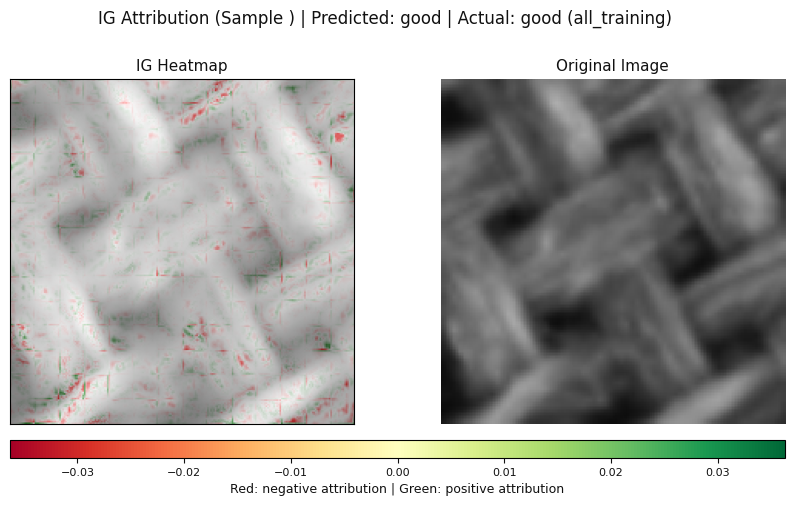

/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


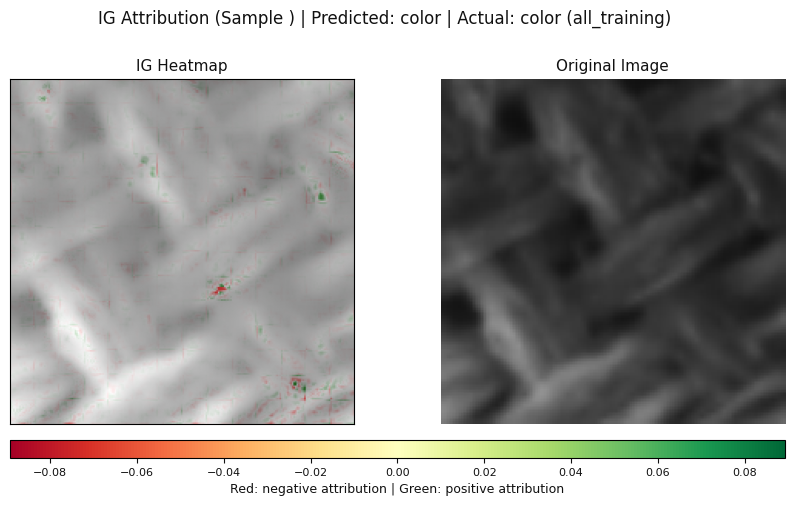

/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


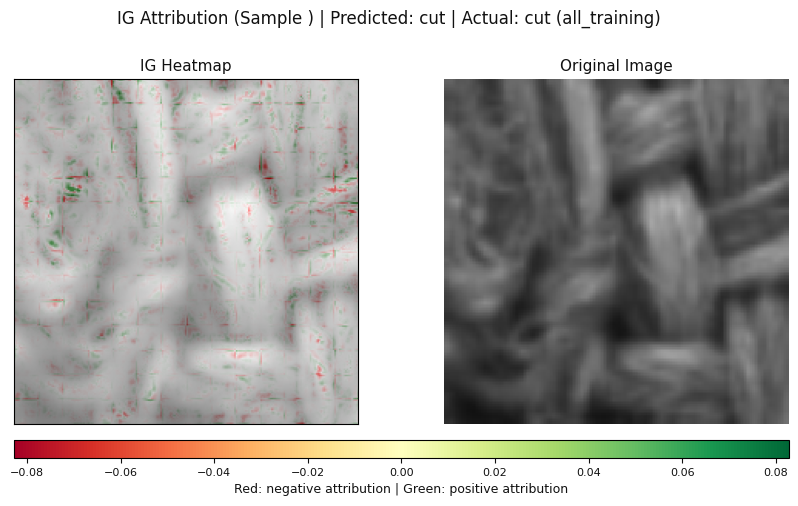

/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


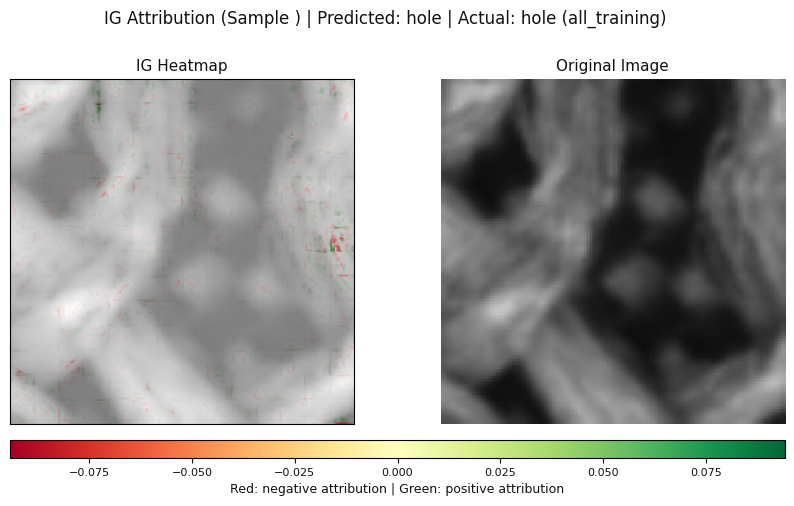

/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


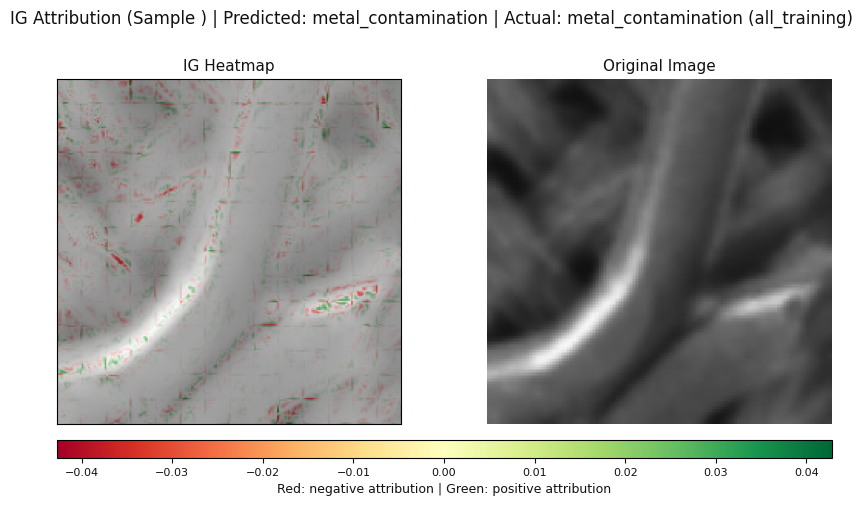

/tmp/ipykernel_6696/1606103627.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))


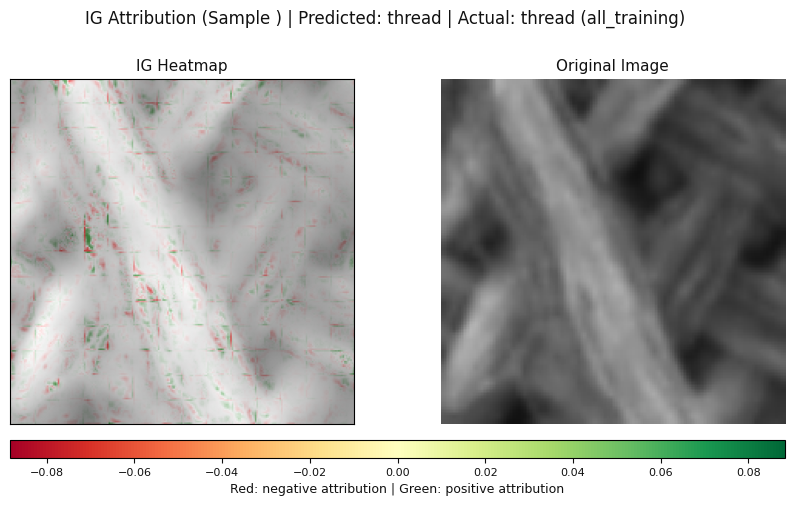

In [43]:
# --- INTEGRATED GRADIENTS FOR ViT (TEXTILE PROJECT) ---
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

# 1. WRAPPER FOR HUGGINGFACE OUTPUTS
# Captum expects a function that returns a [Batch, Num_Classes] Tensor of logits.
def vit_forward_wrapper(input_tensor):
    outputs = model(pixel_values=input_tensor)
    return outputs.logits

# 2. DE-NORMALIZATION UTILITY
# Converts the normalized ViT tensor back to 0-1 range for clear visualization.
def de_normalize(img_tensor, processor):
    mean = torch.tensor(processor.image_mean).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor(processor.image_std).view(3, 1, 1).to(img_tensor.device)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)

# 3. CORE ATTRIBUTION LOGIC
def get_vit_attributions(model, processor, raw_image, target_class_id):
    model.eval()
    # Process image exactly like the training pipeline
    inputs = processor(raw_image, return_tensors="pt").to(device)
    input_tensor = inputs['pixel_values'].requires_grad_(True)
    pred_id = np.argmax(vit_forward_wrapper(input_tensor).detach().cpu().numpy(), axis=-1)

    ig = IntegratedGradients(vit_forward_wrapper)
    baseline = torch.zeros_like(input_tensor).to(device)
    blurrer = GaussianBlur(kernel_size=(21, 21), sigma=(5.0, 5.0))
    blurred_baseline = blurrer(input_tensor)

    # Calculate IG
    attributions = ig.attribute(input_tensor, blurred_baseline, target=int(target_class_id))

    # Prepare for plotting: De-normalize and convert to HWC
    img_for_plot = de_normalize(input_tensor[0], processor)

    # Teacher's format conversion (_to_hwc from your provided code)
    attrs_hwc = _to_hwc(attributions.detach().cpu().numpy())
    img_hwc = _to_hwc(img_for_plot.detach().cpu().numpy())

    return attrs_hwc, img_hwc, pred_id

# 4. EXECUTION LOOP: RUN ONE PER DEFECT CLASS
print("Generating Interpretability Heatmaps for current scenario...")
label_map = load_or_create_label_map(OUT_CSV)
test_ds = ViTTransferDataset(
    csv_path=PROCESSED / "test_split.csv",
    h5_path=PROCESSED / "full64.h5",
    label_map=label_map
  )

# We use your 'train_label_map' which was defined in the training loop
chosen_indices = [9, 9016, 18026, 24007, 32044, 42008]

defect_classes = _defect_classes(label_map)
target_class_ids = {class_id for _, class_id in defect_classes}
#sample_indices = _first_sample_index_per_class(test_ds, target_class_ids)
#sample_indices = get_specific_indices(test_ds, chosen_indices)

for idx in chosen_indices:
    # Get sample from test set
    item = test_ds[idx]
    class_id = item['label']
    # Handle both dict and tuple dataset returns
    raw_img = item["image"] if isinstance(item, dict) else item[0]

    # Calculate
    attrs, img_plot, pred_class = get_vit_attributions(model, processor, raw_img, class_id)

    # Use teacher's plotting function
    # We pass 'class_id' for both pred and actual for the demo visualization
    plot_ig_results(
        attrs,
        img_plot,
        predicted_class=pred_class,
        actual_class=class_id,
        label_map=label_map,
        sample_idx=f""
    )

In [31]:
print(type(test_ds[0]))

<class 'dict'>


In [ ]:
from torchinfo import summary

MODELS = ROOT / "data" / "models"
model_path = MODELS / "ViT-0-1-6" # Replace with your specific folder name

# 2. Load the processor (needed for the data collator)
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

# 3. Load the model
# You don't need num_labels or ignore_mismatched_sizes here
# because the saved config.json already has your custom 6-class head info.
reloaded_model = AutoModelForImageClassification.from_pretrained(model_path)

for name, param in reloaded_model.named_parameters():
      if "classifier" not in name:
          param.requires_grad = False

# 4. Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
reloaded_model.to(device)

summary(reloaded_model, input_size=(1, 3, 224, 224))


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [1, 6]                    --
├─ViTModel: 1-1                                         [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             (590,592)
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [1, 197, 768]             --
│    │    └─ModuleList: 3-3                             --                        (85,054,464)
│    └─LayerNorm: 2-3                                   [1, 197, 768]             (1,536)
├─Linear: 1-2                                           [1, 6]                    4,614
Total params: 85,803,270
Trainable params: 4,614
Non-trainable params: 85,798,656
Total mult-adds (Units.MEGABYTES)

In [12]:
MODELS = ROOT / "data" / "models"
model_path = MODELS / "ViT-0-1-6"
image_folder = ROOT / "data" / "raw" / "SEM" # Update this path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Model and Processor
# Using the "Source" for processor if it's missing from your Drive folder
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = AutoModelForImageClassification.from_pretrained(model_path).to(device)
model.eval() # Set to evaluation mode

id2label = {0: "good", 1: "cut", 2: "color", 3: "metal_contamination", 4: "hole", 5: "thread"}
label2id = {v: k for k, v in id2label.items()}
model.config.id2label = id2label
model.config.label2id = label2id

# Get class names from the model config
class_names = [model.config.id2label[i] for i in range(len(model.config.id2label))]

results = []

# 2. Process Images
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:5]

for filename in image_files:
    img_path = os.path.join(image_folder, filename)
    image = Image.open(img_path).convert("RGB")

    # Preprocess (Resize to 224, Normalize, Convert to Tensor)
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.cpu().numpy()[0] # Get the raw scores

    # Create a dictionary for the table row
    row = {"File Name": filename}
    for i, class_name in enumerate(class_names):
        row[class_name] = round(float(logits[i]), 4)

    # Add the predicted class for clarity
    row["Prediction"] = class_names[logits.argmax()]
    results.append(row)

# 3. Display as a Table
df_results = pd.DataFrame(results)
display(df_results)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

,File Name,good,cut,color,metal_contamination,hole,thread,Prediction
0,10core3shell.png,4.7437,-3.4911,-3.6065,-2.4365,-0.6699,0.9233,good
1,10core4shell.png,3.5430,-2.1974,-3.5708,-3.6733,-0.1775,0.5292,good
2,9core2shell.png,-0.2349,1.2292,-0.4144,-6.1158,0.3626,-0.8776,cut
3,12core2shell.png,2.3525,-1.4691,-8.6851,0.3640,1.1393,1.9033,good
4,12core4shell.png,4.7172,-1.0359,-1.7658,-2.3159,0.1638,-4.5034,good


<Axes: >

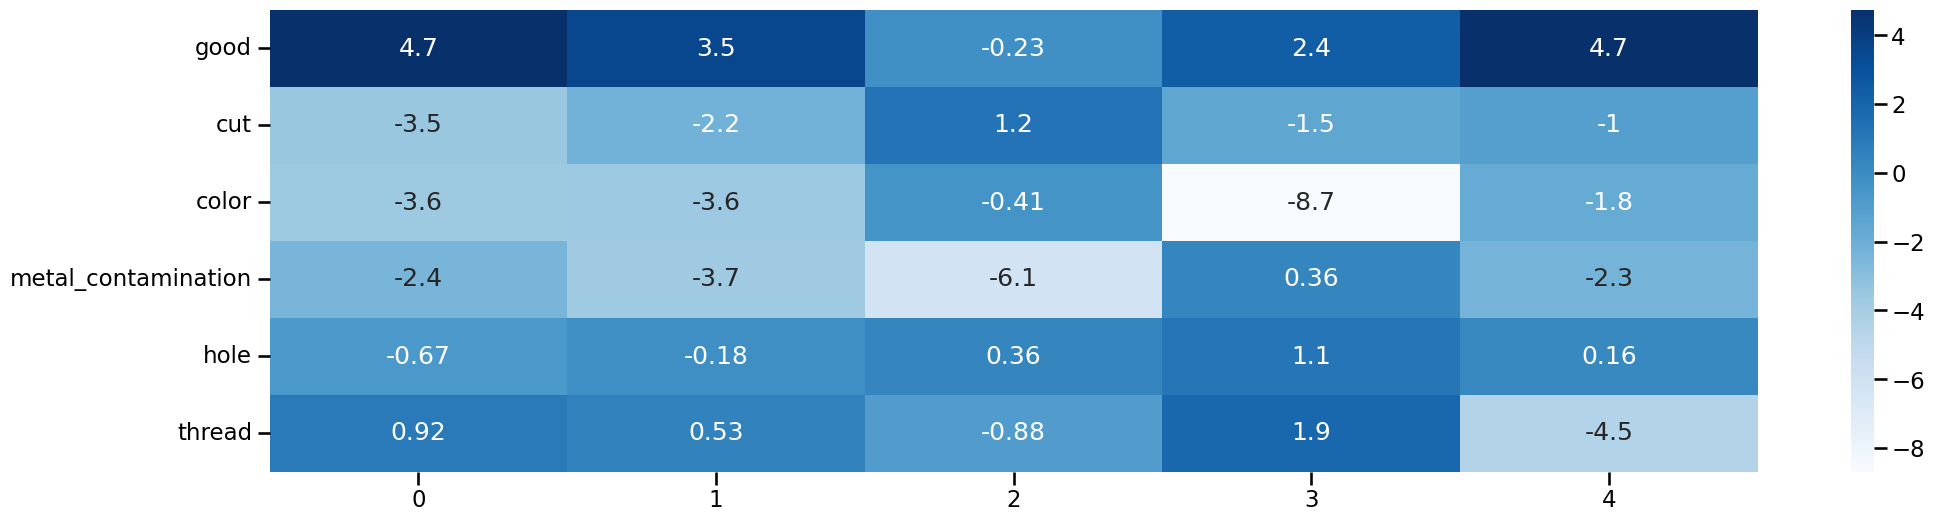

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

trimmed_df = df_results[["good", 'cut', 'color', 'metal_contamination', 'hole', 'thread']]

SEM_logits_array = trimmed_df.to_numpy()
SEM_logits_array = np.transpose(SEM_logits_array)

plt.figure(figsize=(24, 6))
sns.set_context("talk")
sns.heatmap(trimmed_df.T, annot=True, cmap='Blues')